In [ ]:
!pip install torch torchvision torchaudio
!pip install pillow matplotlib tqdm scikit-image opencv-python

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/colab/GAN"

os.makedirs(project_path, exist_ok=True)

print(project_path)

/content/drive/MyDrive/colab/GAN


In [ ]:
%cd /content

!wget https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip

/content
--2026-05-08 15:44:51--  https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip
Resolving data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)... 129.132.52.178, 2001:67c:10ec:36c2::178
Connecting to data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)|129.132.52.178|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3530603713 (3.3G) [application/zip]
Saving to: ‘DIV2K_train_HR.zip’

DIV2K_train_HR.zip  100%[===================>]   3.29G  20.8MB/s    in 2m 48s  

2026-05-08 15:47:40 (20.0 MB/s) - ‘DIV2K_train_HR.zip’ saved [3530603713/3530603713]



In [ ]:
%cd /content

/content


In [ ]:
!unzip -q DIV2K_train_HR.zip

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import (
    Compose,
    RandomCrop,
    ToTensor,
    ToPILImage,
    Resize
)

from torchvision.models import vgg16

from PIL import Image

import os

In [ ]:
class SRDataset(Dataset):

    def __init__(self, image_dir,
                 crop_size=96,
                 upscale_factor=4):

        self.image_dir = image_dir
        self.images = os.listdir(image_dir)

        self.hr_transform = Compose([
            RandomCrop(crop_size),
            ToTensor()
        ])

        self.lr_transform = Compose([
            ToPILImage(),
            Resize(
                crop_size // upscale_factor,
                interpolation=Image.BICUBIC
            ),
            ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        hr = Image.open(img_path).convert("RGB")

        hr = self.hr_transform(hr)

        lr = self.lr_transform(hr)

        return lr, hr

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
dataset = SRDataset(
    "/content/DIV2K_train_HR"
)

print("Dataset size:", len(dataset))

Dataset size: 800


In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [ ]:
import torch
import torch.nn as nn


class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),

            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):

        return x + self.block(x)


class UpsampleBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels * 4, kernel_size=3, stride=1, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )

    def forward(self, x):

        return self.block(x)


class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, stride=1, padding=4),
            nn.PReLU()
        )

        self.residuals = nn.Sequential(
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64)
        )

        self.convblock = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64)
        )

        self.upsample = nn.Sequential(
            UpsampleBlock(64),
            UpsampleBlock(64)
        )

        self.final = nn.Conv2d(
            64,
            3,
            kernel_size=9,
            stride=1,
            padding=4
        )

    def forward(self, x):

        initial = self.initial(x)

        x = self.residuals(initial)

        x = self.convblock(x)

        x = x + initial

        x = self.upsample(x)

        x = self.final(x)

        return torch.tanh(x)

In [ ]:
G = Generator()

print(G)

Generator(
  (initial): Sequential(
    (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): PReLU(num_parameters=1)
  )
  (residuals): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, m

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)

In [ ]:
import torch.nn as nn


def disc_block(in_c, out_c, stride):

    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, stride, 1),
        nn.BatchNorm2d(out_c),
        nn.LeakyReLU(0.2, inplace=True)
    )


class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3, 64, 3, 1, 1),
            nn.LeakyReLU(0.2),

            disc_block(64, 64, 2),
            disc_block(64, 128, 1),
            disc_block(128, 128, 2),

            disc_block(128, 256, 1),
            disc_block(256, 256, 2),

            disc_block(256, 512, 1),
            disc_block(512, 512, 2),

            nn.AdaptiveAvgPool2d(1),

            nn.Conv2d(512, 1024, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(1024, 1, 1)
        )

    def forward(self, x):

        return self.model(x).view(x.size(0))

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)

D = Discriminator().to(device)

print(device)
print("Generator and Discriminator loaded.")

cuda
Generator and Discriminator loaded.


In [ ]:
from torchvision.models import vgg16


class VGGLoss(nn.Module):

    def __init__(self):

        super().__init__()

        vgg = vgg16(weights='DEFAULT').features

        self.layers = nn.ModuleList([
            vgg[:4],
            vgg[:9],
            vgg[:16]
        ])

        for p in self.parameters():
            p.requires_grad = False

        self.weights = [0.2, 0.3, 0.5]

        self.mse = nn.MSELoss()

    def forward(self, sr, hr):

        loss = 0

        for weight, layer in zip(self.weights, self.layers):

            sr_feat = layer(sr)

            hr_feat = layer(hr)

            loss += weight * self.mse(sr_feat, hr_feat)

        return loss

In [ ]:
from torch.utils.data import Dataset
from torchvision.transforms import (
    Compose,
    RandomCrop,
    ToTensor,
    ToPILImage,
    Resize
)

from PIL import Image
import os


class SRDataset(Dataset):

    def __init__(self,
                 image_dir,
                 crop_size=96,
                 upscale_factor=4):

        self.image_dir = image_dir

        self.images = os.listdir(image_dir)

        self.hr_transform = Compose([
            RandomCrop(crop_size),
            ToTensor()
        ])

        self.lr_transform = Compose([
            ToPILImage(),

            Resize(
                crop_size // upscale_factor,
                interpolation=Image.BICUBIC
            ),

            ToTensor()
        ])

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        hr = Image.open(img_path).convert("RGB")

        hr = self.hr_transform(hr)

        lr = self.lr_transform(hr)

        return lr, hr

In [ ]:
from torch.utils.data import DataLoader

dataset = SRDataset("/content/DIV2K_train_HR")

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("Dataset size:", len(dataset))

Dataset size: 800


In [ ]:
lr, hr = next(iter(loader))

lr = lr.to(device)

hr = hr.to(device)

fake = G(lr)

print("LR:", lr.shape)

print("HR:", hr.shape)

print("SR:", fake.shape)

LR: torch.Size([4, 3, 24, 24])
HR: torch.Size([4, 3, 96, 96])
SR: torch.Size([4, 3, 96, 96])


In [ ]:
import torch.optim as optim

vgg_loss = VGGLoss().to(device)

bce = nn.BCEWithLogitsLoss()

opt_G = optim.Adam(
    G.parameters(),
    lr=1e-4
)

opt_D = optim.Adam(
    D.parameters(),
    lr=1e-4
)

print("Everything ready.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 182MB/s]


Everything ready.


In [ ]:
from torch.utils.data import random_split

full_dataset = SRDataset("/content/DIV2K_train_HR")

train_size = int(0.8 * len(full_dataset))

val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 640
Validation size: 160


In [ ]:
import matplotlib.pyplot as plt

EPOCHS = 300

train_g_losses = []
train_d_losses = []

val_g_losses = []

for epoch in range(EPOCHS):

    # =========================
    # TRAINING
    # =========================

    G.train()
    D.train()

    epoch_g_loss = 0
    epoch_d_loss = 0

    for batch_idx, (lr, hr) in enumerate(train_loader):

        lr = lr.to(device)
        hr = hr.to(device)

        # ======================
        # Generator forward
        # ======================

        fake = G(lr)

        # ======================
        # Train discriminator
        # ======================

        real_out = D(hr)

        fake_out = D(fake.detach())

        d_loss_real = bce(
            real_out,
            torch.ones_like(real_out)
        )

        d_loss_fake = bce(
            fake_out,
            torch.zeros_like(fake_out)
        )

        d_loss = d_loss_real + d_loss_fake

        opt_D.zero_grad()

        d_loss.backward()

        opt_D.step()

        # ======================
        # Train generator
        # ======================

        fake_out = D(fake)

        perceptual_loss = vgg_loss(fake, hr)

        adv_loss = bce(
            fake_out,
            torch.ones_like(fake_out)
        )

        g_loss = perceptual_loss + 0.001 * adv_loss

        opt_G.zero_grad()

        g_loss.backward()

        opt_G.step()

        epoch_g_loss += g_loss.item()

        epoch_d_loss += d_loss.item()

    # =========================
    # AVERAGE TRAIN LOSSES
    # =========================

    avg_g_loss = epoch_g_loss / len(train_loader)

    avg_d_loss = epoch_d_loss / len(train_loader)

    train_g_losses.append(avg_g_loss)

    train_d_losses.append(avg_d_loss)

    # =========================
    # VALIDATION
    # =========================

    G.eval()

    val_loss = 0

    with torch.no_grad():

        for lr, hr in val_loader:

            lr = lr.to(device)
            hr = hr.to(device)

            fake = G(lr)

            perceptual = vgg_loss(fake, hr)

            val_loss += perceptual.item()

    avg_val_loss = val_loss / len(val_loader)

    val_g_losses.append(avg_val_loss)

    # =========================
    # PRINT
    # =========================

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train G: {avg_g_loss:.4f} "
        f"Train D: {avg_d_loss:.4f} "
        f"Val G: {avg_val_loss:.4f}"
    )

    # =========================
    # SAVE CHECKPOINT
    # =========================

    torch.save(
        G.state_dict(),
        f"/content/drive/MyDrive/colab/GAN/generator_epoch_{epoch+1}.pth"
    )

Epoch [1/300] Train G: 0.8843 Train D: 0.0068 Val G: 0.8014
Epoch [2/300] Train G: 0.8935 Train D: 0.0102 Val G: 0.7513
Epoch [3/300] Train G: 0.8769 Train D: 0.0068 Val G: 0.8047
Epoch [4/300] Train G: 0.8719 Train D: 0.1242 Val G: 0.7821
Epoch [5/300] Train G: 0.8833 Train D: 0.0669 Val G: 0.7515
Epoch [6/300] Train G: 0.9182 Train D: 0.1459 Val G: 0.8809
Epoch [7/300] Train G: 0.8762 Train D: 0.0115 Val G: 0.8031
Epoch [8/300] Train G: 0.8399 Train D: 0.0049 Val G: 0.8136
Epoch [9/300] Train G: 0.8846 Train D: 0.1761 Val G: 0.7854
Epoch [10/300] Train G: 0.8902 Train D: 0.1428 Val G: 0.8763
Epoch [11/300] Train G: 0.8361 Train D: 0.0825 Val G: 0.7349
Epoch [12/300] Train G: 0.8606 Train D: 0.0416 Val G: 0.8217
Epoch [13/300] Train G: 0.9187 Train D: 0.0042 Val G: 0.7626
Epoch [14/300] Train G: 0.8238 Train D: 0.0037 Val G: 0.8580
Epoch [15/300] Train G: 0.8737 Train D: 0.0048 Val G: 0.7688
Epoch [16/300] Train G: 0.8497 Train D: 0.0151 Val G: 0.7942
Epoch [17/300] Train G: 0.8211 Tr

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)

checkpoint_path = "/content/drive/MyDrive/colab/GAN/generator_epoch_168.pth"

G.load_state_dict(
    torch.load(checkpoint_path)
)

G.eval()

print("Checkpoint loaded.")

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)

checkpoint_path = "/content/drive/MyDrive/colab/GAN/generator_epoch_168.pth"

G.load_state_dict(torch.load(checkpoint_path))

G.eval()

print("Checkpoint loaded successfully.")

Checkpoint loaded successfully.


In [ ]:
SRResNet = Generator().to(device)

SRResNet.load_state_dict(torch.load(checkpoint_path))

SRResNet.eval()

print("SRResNet ready.")

SRResNet ready.


In [ ]:
import matplotlib.pyplot as plt

train_g_losses = []
train_d_losses = []
val_g_losses = []

In [ ]:
START_EPOCH = 168
EPOCHS = 200

for epoch in range(START_EPOCH, EPOCHS):

    G.train()
    D.train()

    epoch_g_loss = 0
    epoch_d_loss = 0

    for batch_idx, (lr, hr) in enumerate(train_loader):

        lr = lr.to(device)
        hr = hr.to(device)

        # Generator forward
        fake = G(lr)

        # ======================
        # Train discriminator
        # ======================

        real_out = D(hr)

        fake_out = D(fake.detach())

        d_loss_real = bce(
            real_out,
            torch.ones_like(real_out)
        )

        d_loss_fake = bce(
            fake_out,
            torch.zeros_like(fake_out)
        )

        d_loss = d_loss_real + d_loss_fake

        opt_D.zero_grad()

        d_loss.backward()

        opt_D.step()

        # ======================
        # Train generator
        # ======================

        fake_out = D(fake)

        perceptual_loss = vgg_loss(fake, hr)

        adv_loss = bce(
            fake_out,
            torch.ones_like(fake_out)
        )

        g_loss = perceptual_loss + 0.001 * adv_loss

        opt_G.zero_grad()

        g_loss.backward()

        opt_G.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()

    # ======================
    # Average losses
    # ======================

    avg_g_loss = epoch_g_loss / len(train_loader)
    avg_d_loss = epoch_d_loss / len(train_loader)

    train_g_losses.append(avg_g_loss)
    train_d_losses.append(avg_d_loss)

    # ======================
    # Validation
    # ======================

    G.eval()

    val_loss = 0

    with torch.no_grad():

        for lr, hr in val_loader:

            lr = lr.to(device)
            hr = hr.to(device)

            fake = G(lr)

            perceptual = vgg_loss(fake, hr)

            val_loss += perceptual.item()

    avg_val_loss = val_loss / len(val_loader)

    val_g_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train G: {avg_g_loss:.4f} "
        f"Train D: {avg_d_loss:.4f} "
        f"Val G: {avg_val_loss:.4f}"
    )

    # Save checkpoint

    torch.save(
        G.state_dict(),
        f"/content/drive/MyDrive/colab/GAN/generator_epoch_{epoch+1}.pth"
    )

Epoch [169/200] Train G: 0.6917 Train D: 0.7802 Val G: 0.6775
Epoch [170/200] Train G: 0.7112 Train D: 0.2925 Val G: 0.7713
Epoch [171/200] Train G: 0.7127 Train D: 0.3657 Val G: 0.7411
Epoch [172/200] Train G: 0.6879 Train D: 0.1452 Val G: 0.7850
Epoch [173/200] Train G: 0.6742 Train D: 0.0576 Val G: 0.7890
Epoch [174/200] Train G: 0.7211 Train D: 0.1377 Val G: 0.7750
Epoch [175/200] Train G: 0.7195 Train D: 0.0706 Val G: 0.8126
Epoch [176/200] Train G: 0.7222 Train D: 0.0261 Val G: 0.8063
Epoch [177/200] Train G: 0.6913 Train D: 0.0207 Val G: 0.7917
Epoch [178/200] Train G: 0.7110 Train D: 0.1143 Val G: 0.7403
Epoch [179/200] Train G: 0.7329 Train D: 0.0278 Val G: 0.7477
Epoch [180/200] Train G: 0.7143 Train D: 0.0128 Val G: 0.7403
Epoch [181/200] Train G: 0.6866 Train D: 0.0388 Val G: 0.8253
Epoch [182/200] Train G: 0.7032 Train D: 0.1469 Val G: 0.7221
Epoch [183/200] Train G: 0.7214 Train D: 0.0198 Val G: 0.8406
Epoch [184/200] Train G: 0.7367 Train D: 0.0200 Val G: 0.7131
Epoch [1

In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

from PIL import Image

import torchvision.transforms as T

import numpy as np

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

In [2]:
class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),

            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):

        return x + self.block(x)


class UpsampleBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )

    def forward(self, x):

        return self.block(x)


class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, 9, 1, 4),
            nn.PReLU()
        )

        self.residuals = nn.Sequential(
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64)
        )

        self.convblock = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64)
        )

        self.upsample = nn.Sequential(
            UpsampleBlock(64),
            UpsampleBlock(64)
        )

        self.final = nn.Conv2d(64, 3, 9, 1, 4)

    def forward(self, x):

        initial = self.initial(x)

        x = self.residuals(initial)

        x = self.convblock(x)

        x = x + initial

        x = self.upsample(x)

        x = self.final(x)

        return torch.clamp(x, 0, 1)

In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)

checkpoint_path = "/content/drive/MyDrive/colab/GAN/generator_epoch_200.pth"

G.load_state_dict(
    torch.load(checkpoint_path)
)

G.eval()

print("Checkpoint 200 loaded successfully.")

Checkpoint 200 loaded successfully.


In [9]:
from skimage import data

from PIL import Image

import numpy as np

astronaut = data.astronaut()

hr_image = Image.fromarray(astronaut)

print(hr_image.size)

(512, 512)


In [10]:
w, h = hr_image.size

# Create low-resolution image

lr_image = hr_image.resize(
    (w // 4, h // 4),
    Image.BICUBIC
)

# Bicubic upscale

bicubic_image = lr_image.resize(
    (w, h),
    Image.BICUBIC
)

print("HR:", hr_image.size)

print("LR:", lr_image.size)

HR: (512, 512)
LR: (128, 128)


In [11]:
import torchvision.transforms as T

transform = T.ToTensor()

lr_tensor = transform(lr_image).unsqueeze(0).to(device)

with torch.no_grad():

    sr_tensor = G(lr_tensor)

sr_tensor = sr_tensor.squeeze(0).cpu().clamp(0,1)

srgan_image = T.ToPILImage()(sr_tensor)

print("SRGAN inference complete.")

SRGAN inference complete.


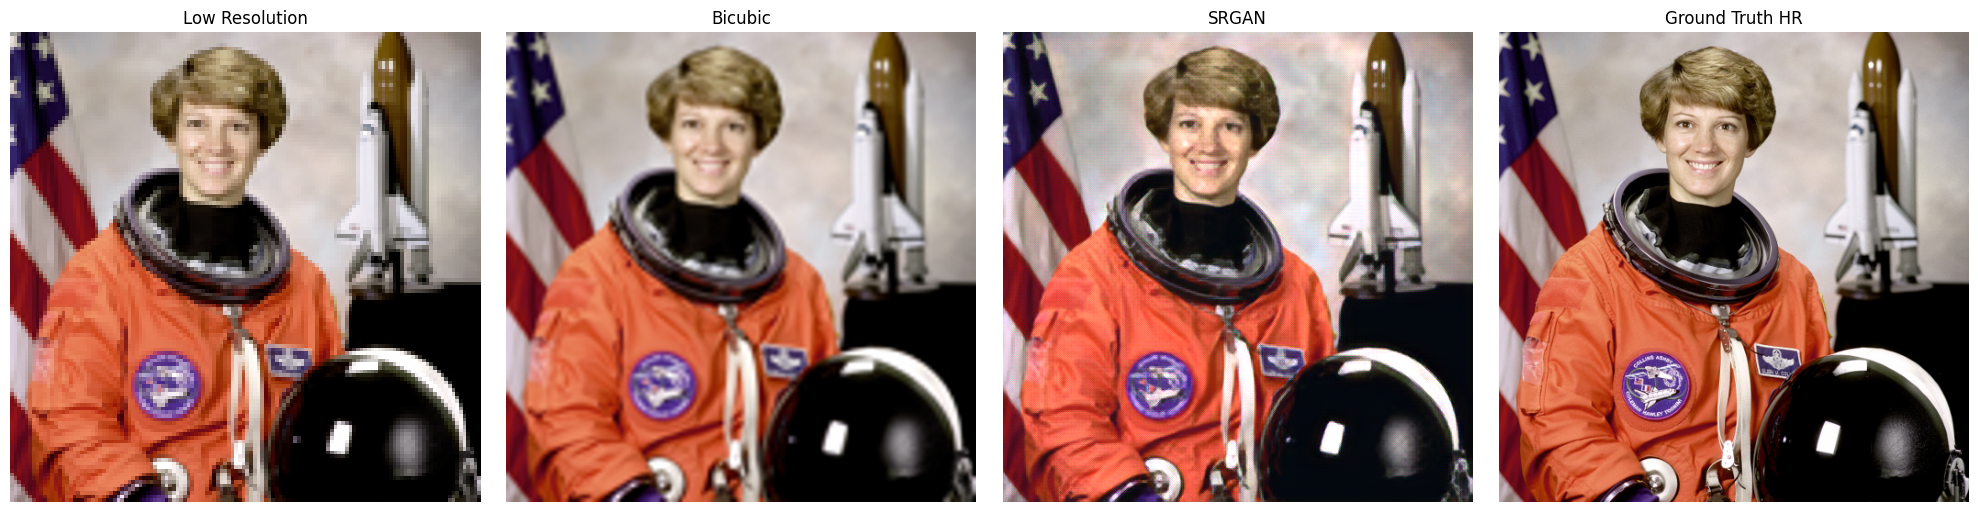

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

# Low Resolution

plt.subplot(1,4,1)
plt.imshow(lr_image)
plt.title("Low Resolution")
plt.axis("off")

# Bicubic

plt.subplot(1,4,2)
plt.imshow(bicubic_image)
plt.title("Bicubic")
plt.axis("off")

# SRGAN

plt.subplot(1,4,3)
plt.imshow(srgan_image)
plt.title("SRGAN")
plt.axis("off")

# Ground Truth

plt.subplot(1,4,4)
plt.imshow(hr_image)
plt.title("Ground Truth HR")
plt.axis("off")

plt.tight_layout()

plt.show()

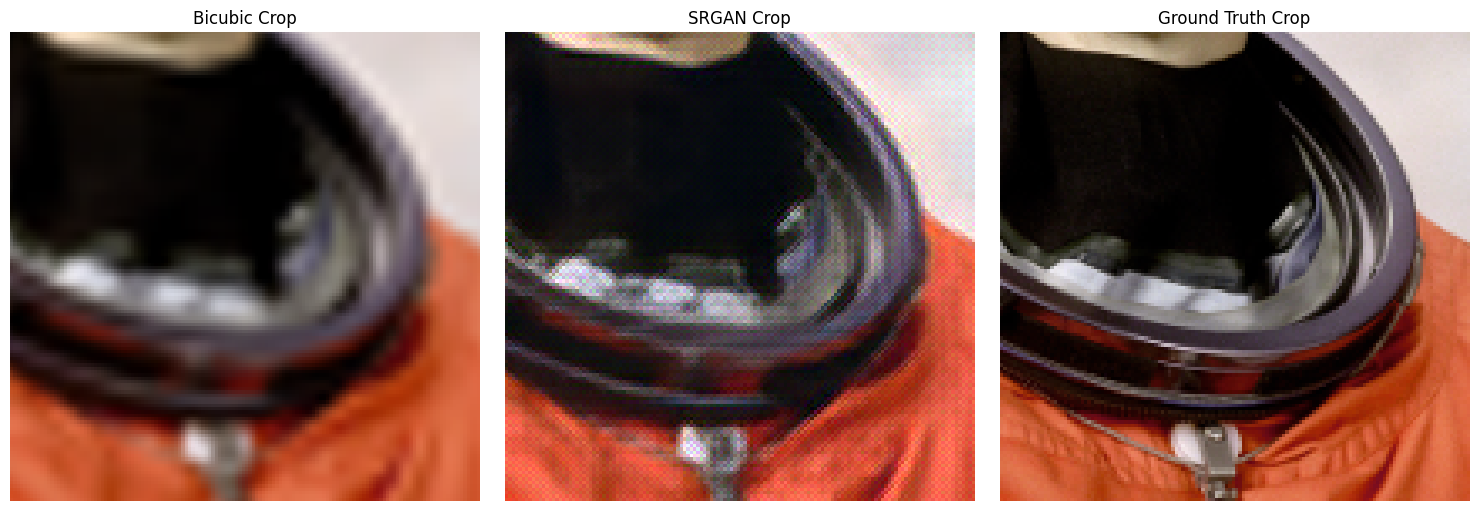

In [13]:
crop_box = (180, 180, 320, 320)

hr_crop = hr_image.crop(crop_box)

bicubic_crop = bicubic_image.crop(crop_box)

srgan_crop = srgan_image.crop(crop_box)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(bicubic_crop)
plt.title("Bicubic Crop")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(srgan_crop)
plt.title("SRGAN Crop")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hr_crop)
plt.title("Ground Truth Crop")
plt.axis("off")

plt.tight_layout()

plt.show()

In [14]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

hr_np = np.array(hr_image)

bicubic_np = np.array(bicubic_image)

srgan_np = np.array(srgan_image)

# PSNR

psnr_bicubic = peak_signal_noise_ratio(
    hr_np,
    bicubic_np
)

psnr_srgan = peak_signal_noise_ratio(
    hr_np,
    srgan_np
)

# SSIM

ssim_bicubic = structural_similarity(
    hr_np,
    bicubic_np,
    channel_axis=2
)

ssim_srgan = structural_similarity(
    hr_np,
    srgan_np,
    channel_axis=2
)

print("===== Bicubic =====")

print("PSNR:", psnr_bicubic)

print("SSIM:", ssim_bicubic)

print()

print("===== SRGAN =====")

print("PSNR:", psnr_srgan)

print("SSIM:", ssim_srgan)

===== Bicubic =====
PSNR: 25.37841617249861
SSIM: 0.830974430516353

===== SRGAN =====
PSNR: 23.088288070515553
SSIM: 0.5596994244859291


In [15]:
plt.savefig(
    "/content/srgan_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [16]:
plt.savefig(
    "/content/training_curves.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

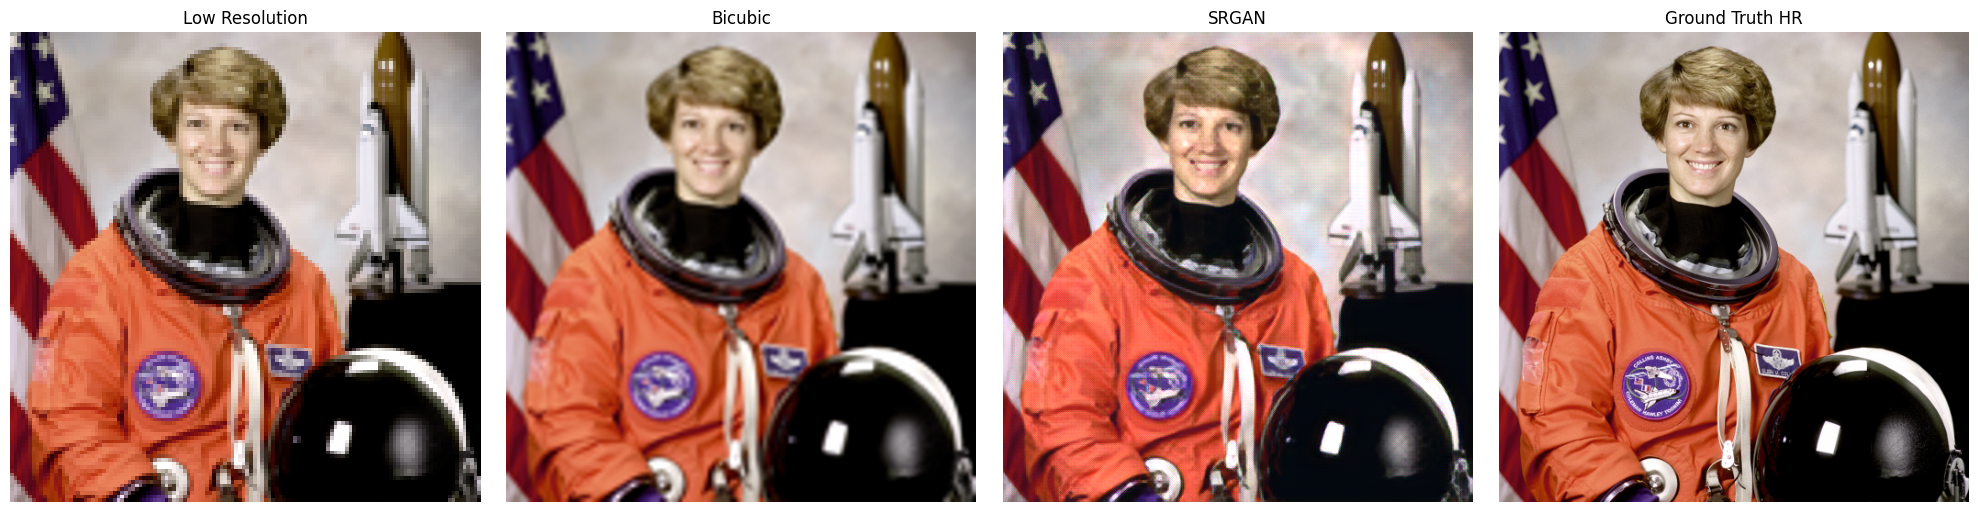

Figure saved successfully.


In [19]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20,5))

# Low Resolution
plt.subplot(1,4,1)
plt.imshow(lr_image)
plt.title("Low Resolution")
plt.axis("off")

# Bicubic
plt.subplot(1,4,2)
plt.imshow(bicubic_image)
plt.title("Bicubic")
plt.axis("off")

# SRGAN
plt.subplot(1,4,3)
plt.imshow(srgan_image)
plt.title("SRGAN")
plt.axis("off")

# Ground Truth
plt.subplot(1,4,4)
plt.imshow(hr_image)
plt.title("Ground Truth HR")
plt.axis("off")

plt.tight_layout()

# SAVE BEFORE SHOW
fig.savefig(
    "/content/srgan_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

In [20]:
from google.colab import files

files.download("/content/srgan_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>